#Day 19 Pengantar Machine Learning & Linear Regression

Mulai sekarang saya akan **membuat model yang memprediksi**. saya akan awali  dengan konsep paling fundamental: **supervised learning** dan **Regresi Linear**, memakai data kualitas anggur merah.

> 🎯 **Tujuan Pembelajaran**

  > - Memahami konsep **supervised learning** (fitur `X` → target `y`).
  > - Mengenal **train/test split** dan kenapa itu penting.
  > - Melatih model **Regresi Linear** (1 fitur lalu banyak fitur) dengan scikit-learn.
  > - Mengevaluasi model dengan **R², MAE, RMSE** dan menafsirkannya.

## 1.Tentang Dataset


**Red Wine Quality** — pengukuran kimia 1.599 sampel anggur merah dan skor kualitasnya.

- **Sumber:** [Kaggle — uciml/red-wine-quality-cortez-et-al-2009](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)

| Kolom (contoh) | Arti |
|----------------|------|
| `alcohol` | Kadar alkohol (% volume) |
| `volatile acidity` | Keasaman volatil (cuka) |
| `sulphates` | Kadar sulfat |
| `quality` | **Target**: skor kualitas (0–10) |

Saya akan **memprediksi `quality`** dari fitur kimia. Karena `quality` adalah **angka**, ini masalah **regresi** (bukan klasifikasi).

## 2.Import Library

- **pandas/numpy** → olah data.
- **matplotlib/seaborn** → visualisasi.
- **scikit-learn** → `train_test_split`, `LinearRegression`, dan metrik evaluasi.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 3.Import Dataset

In [162]:
!pip install -q kaggle
!kaggle datasets download -d uciml/red-wine-quality-cortez-et-al-2009

Dataset URL: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009
License(s): DbCL-1.0
red-wine-quality-cortez-et-al-2009.zip: Skipping, found more recently modified local copy (use --force to force download)


In [163]:
!unzip -q /content/red-wine-quality-cortez-et-al-2009.zip

replace winequality-red.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


## 4.Explorasi Awal

In [164]:
df = pd.read_csv('/content/winequality-red.csv')
df.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [166]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [167]:
df.isnull().sum().sum()

np.int64(0)

Interpretasi :     
  - Semua kolom berupa angka — cocok langsung untuk regresi linear tanpa encoding.
  - Tidak ada nilai hilang.
  - Skor `quality` mayoritas di kisaran 5–6, dengan rentang 3–8.
  - Ini target numerik yang akan diprediksi
  - Kolom terakhir `quality` adalah yang ingin kita prediksi.

## 5. Konsep : Supervised Learning

Pada **supervised learning**, kita punya:
- **`X` (fitur)** — variabel masukan, mis. kadar alkohol.
- **`y` (target/label)** — yang ingin diprediksi, mis. skor `quality`.


Model belajar **pola** dari pasangan (X, y) pada **data latih**, lalu diuji pada **data uji** yang belum pernah dilihat. Membagi data (train/test split) penting agar kita tahu model **benar-benar belajar**, bukan sekadar menghafal.

## 5.EDA dan Visulisasi

### a) Kolerasi Fitur dengan Quality

Lihat fitur mana yang paling berpengaruh denga kualitas

In [168]:
korelasi = df.corr(numeric_only=True)['quality'].sort_values(ascending=False)
korelasi = korelasi.drop("quality")
korelasi

,quality
alcohol,0.476166
sulphates,0.251397
citric acid,0.226373
fixed acidity,0.124052
residual sugar,0.013732
free sulfur dioxide,-0.050656
pH,-0.057731
chlorides,-0.128907
density,-0.174919
total sulfur dioxide,-0.185100


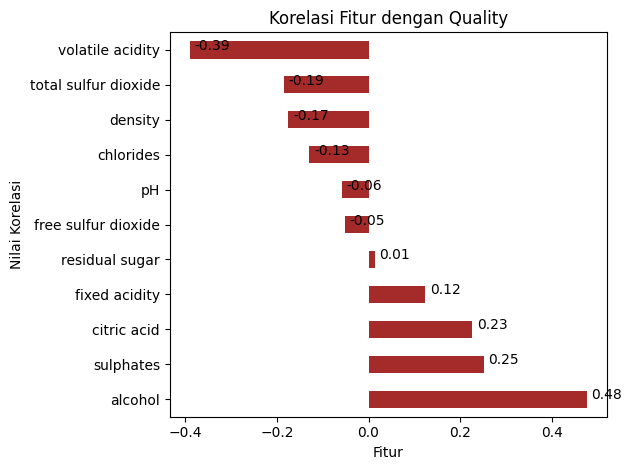

In [169]:
korelasi.plot(kind='barh',
              title='Korelasi Fitur dengan Quality',
              color='brown')
plt.xlabel('Fitur')
plt.ylabel('Nilai Korelasi')
for i, v in enumerate(korelasi):
    plt.text(v + 0.01, i, str(round(v, 2)), color='black', fontweight='1')
plt.tight_layout()
plt.show()

Interpretasi:
  - Alkohol punya korelasi positif yang kuat terhadap `quality`
  - `volatile acid` berkorelasi negatif paling besar dengan quality
  - alkohol aalah kandidat fitu tuggal terbaik untuk model pertama yanga akan kita coba

### b) Hubungan Alcohol dengan Quality

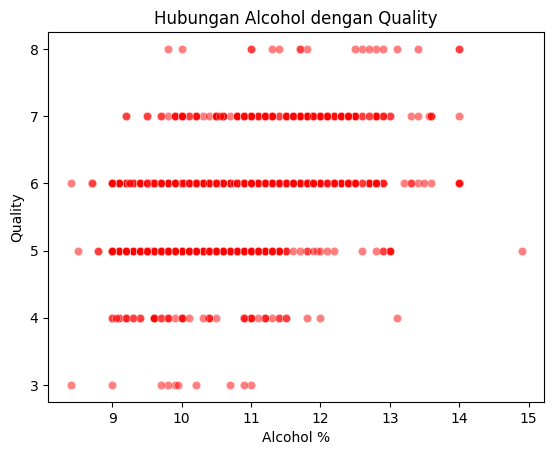

In [170]:
sns.scatterplot(data=df, x='alcohol', y='quality', color='red', alpha=0.5)
plt.title('Hubungan Alcohol dengan Quality')
plt.xlabel('Alcohol %')
plt.ylabel('Quality')
plt.show()

Interpretasi:
- Terlihat ada indikasi, makin tinggi kadar alkohol, skor kualitas untuk redwine semakin meningkat, walaupun sebarannya cukup melebar
- Regresi linear akan mencoba menarik garis lurus terbaik dari pola ini

### c) Heatmap Korelasi antar Fitur

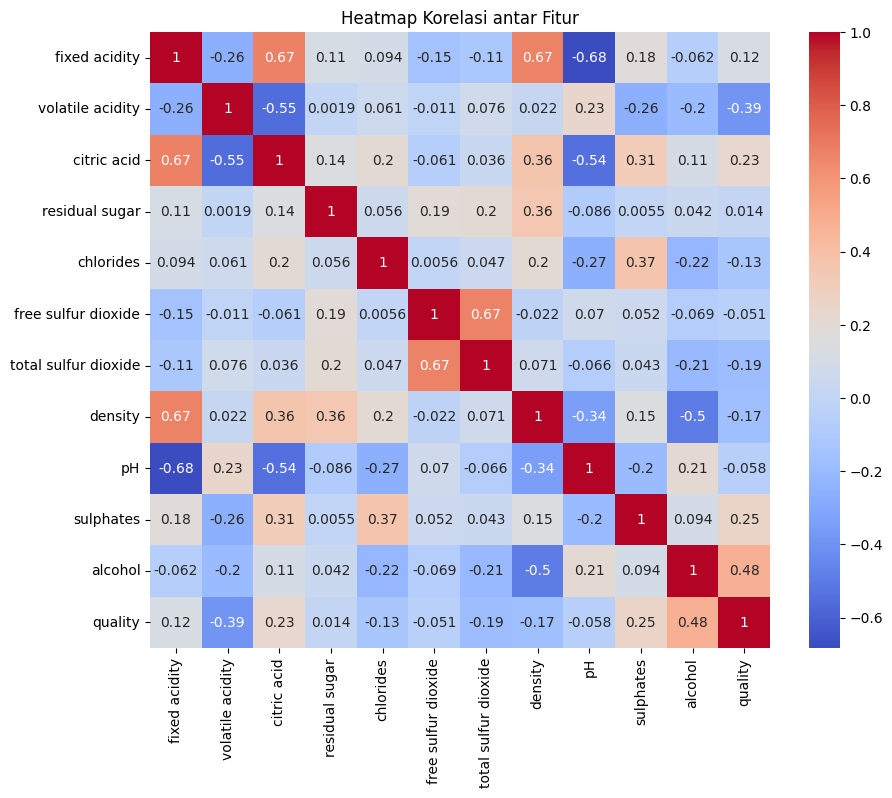

In [171]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi antar Fitur')
plt.show()

Interpretasi:
-  Heatmap membantu mendeteksi fitur yang saling berkorelasi kuat (mis. `free
sulfur dioxide` dan `total sulfur dioxide`).
- Untuk regresi linear, korelasi antar fitur yang terlalu tinggi bisa membuat koefisien sulit ditafsirkan (multikolinearitas).

## 6.BaseModel - Linear Regression with 1 Feature

Saya mulai paling sederhana: prediksi `quality` hanya dari `alcohol`.

Langkah:
1. Pisahkan `X` dan `y`.
2. Bagi data 80% latih / 20% uji (`random_state=42` agar hasil dapat direproduksi).
3. Latih `LinearRegression`.

In [172]:
#Split X dan y
X = df[['alcohol']]
y = df['quality']

In [173]:
#Split data latih dan data testing ( X_train,X_test, y_train, y_test)
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [174]:
base_model = LinearRegression()
base_model.fit(X_train, y_train)

LinearRegression()

In [175]:
print(f"Intercept: {base_model.intercept_:.2f}")
print(f"Koefisien: {base_model.coef_[0]:.2f}")

Intercept: 1.85
Koefisien: 0.36


Interpretasi:
 -  Model membentuk persamaan garis `quality = b + m × alcohol`.
 -  Koefisien positif berarti **setiap kenaikan 1% alkohol** dikaitkan dengan kenaikan skor kualitas sebesar nilai koefisien tersebut.
 - koefisien positif menunjukkan hubungan positif dalam model, bukan otomatis berarti alkohol menyebabkan quality meningkat.

### d) Visualisasi Garis Fit

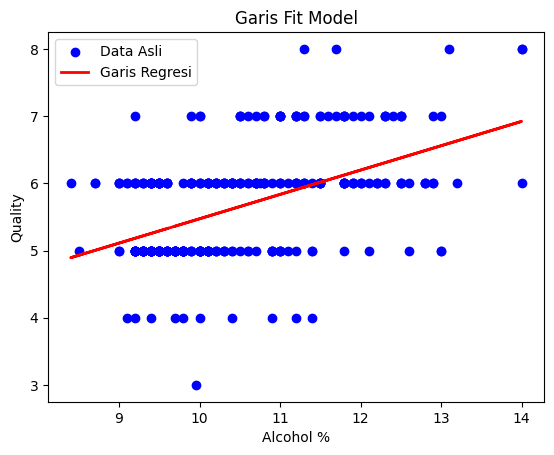

In [176]:
plt.scatter(X_test['alcohol'], y_test, color='blue', label='Data Asli')
plt.plot(X_test['alcohol'], base_model.predict(X_test), color='red', linewidth=2, label='Garis Regresi')
plt.xlabel('Alcohol %')
plt.ylabel('Quality')
plt.title('Garis Fit Model')
plt.legend()
plt.show()

Interpretasi:
-  Garis merah adalah prediksi model
-  Ini menangkap tren `Alkohol tinggi = Kualitas lebihbaik`, tetapi banyak titik yang jauh dari garis - petanda 1 fitur saja belum cukup untuk regresi linear ini

### e) Evaluasi Model 1

### Evaluasi Model 1

Kita ukur dengan tiga metrik:
  - **R²** — proporsi variasi target yang bisa dijelaskan model (1 = sempurna, 0 = tidak lebih baik dari rata-rata).
  - **MAE** — rata-rata selisih absolut prediksi vs aktual (dalam satuan skor).
  - **RMSE** — akar dari rata-rata kuadrat error (menghukum error besar lebih keras).

In [177]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)


    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.2f}")
    return mae, rmse, r2

In [178]:
y_pred_base = base_model.predict(X_test)

In [179]:
Metric_basemodel = evaluate_model(y_test, y_pred_base)

MAE: 0.57
RMSE: 0.71
R²: 0.24


Interpretasi:
  - ✅ MAE 0.57 → model rata-rata melenceng sekitar 0.57 poin quality dari nilai sebenarnya.
  - 🟡 RMSE 0.71 → error model sekitar 0.71 poin, dengan error besar diberi penalti lebih kuat.
  - ✅ R² 0.24 → model hanya mampu menjelaskan sekitar 24% variasi quality berdasarkan alcohol.
  - ⚠️ RMSE > MAE → menunjukkan ada beberapa error yang relatif besar, tetapi belum cukup untuk menyimpulkan pasti ada outlier.

## 7.Model 1 - Linear Regression with all feature

In [180]:
X_fitur = df.drop('quality', axis=1)
y_target = df['quality']

In [181]:
X_train, X_test, y_train, y_test = train_test_split(X_fitur,
                                                    y_target,
                                                    test_size=0.2,
                                                    random_state=42)

In [182]:
model_1 = LinearRegression()
model_1.fit(X_train, y_train)

LinearRegression()

In [183]:
y_pred1 = model_1.predict(X_test)

In [184]:
metrics_1 = evaluate_model(y_test, y_pred1)

MAE: 0.50
RMSE: 0.62
R²: 0.40


Interpretasinya
  - R²: 0.24 → 0.40
Model sekarang mampu menjelaskan 40% variasi quality, naik dari 24%.
    -  Informasi dari fitur tambahan membantu model memahami quality lebih baik.
- MAE: 0.57 → 0.50
Rata-rata kesalahan turun dari 0.57 menjadi 0.50 poin.
    - Prediksi menjadi lebih dekat ke nilai aktual.
- RMSE: 0.71 → 0.62
Error besar juga berkurang.
    - Model dengan 11 fitur menghasilkan prediksi yang lebih baik dibanding hanya menggunakan alcohol.

### f) Evaluasi dan Perbandingan

In [189]:
perbandingan_tabel = pd.DataFrame({
    'Model': ['Metric_basemodel', 'metrics_1'],
    'MAE': [Metric_basemodel[0], metrics_1[0]],
    'RMSE': [Metric_basemodel[1], metrics_1[1]],
    'R2': [Metric_basemodel[2], metrics_1[2]]
})

perbandingan_tabel = perbandingan_tabel.set_index('Model')

perbandingan_tabel

,MAE,RMSE,R2
Model,,,
Metric_basemodel,0.574966,0.706773,0.235618
metrics_1,0.503530,0.624520,0.403180


Interpretasi:  
  - MAE ↓ 0.575 → 0.504 → rata-rata prediksi lebih dekat dengan nilai aktual.
- RMSE ↓ 0.707 → 0.625 → error besar juga lebih rendah.
- R² ↑ 0.236 → 0.403 → kemampuan model menjelaskan variasi quality meningkat dari sekitar 24% → 40%.

### g) Fitur Paling berpengaruh (Koefisien)

In [197]:
koef = pd.Series(model_1.coef_, index=X_fitur.columns).sort_values()
koef

,0
density,-10.351594
chlorides,-1.806503
volatile acidity,-1.001304
pH,-0.393688
citric acid,-0.140821
total sulfur dioxide,-0.003644
free sulfur dioxide,0.005627
residual sugar,0.006564
fixed acidity,0.023085
alcohol,0.281890


Text(0, 0.5, 'Fitur')

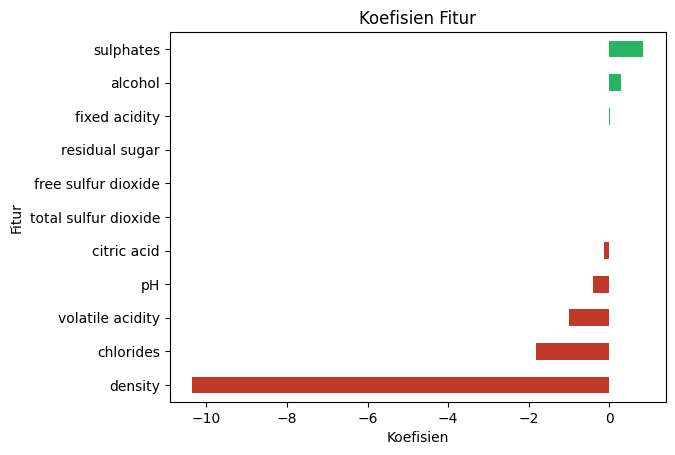

In [198]:
koef.plot(kind='barh',
          title='Koefisien Fitur',
          color=["#C0392B" if v < 0 else "#28B463" for v in koef.values])
plt.xlabel('Koefisien')
plt.ylabel('Fitur')

Interpretasi:
  - Koefisien positif (Hijau) : Menaikan prediksi kualitas
  - Koefisien negatif (Merah) : Menurunkan Prediksi Kualitas

## 8.Kesimpulan dan Insight

- **Regresi linear** memodelkan target numerik sebagai kombinasi berbobot dari fitur.
- **Train/test split** memastikan evaluasi jujur pada data yang belum dilihat model.
- Model **1 fitur** (alcohol) lemah; model **semua fitur** jauh lebih baik (R² naik, RMSE turun).
- **Alcohol** mendorong kualitas naik; **volatile acidity** menurunkannya.
- Tiga metrik (R², MAE, RMSE) memberi sudut pandang berbeda tentang kualitas prediksi.

R² yang masih moderat menunjukkan hubungan kualitas anggur tidak sepenuhnya linear — model
non-linear (Random Forest, dst.) yang kita pelajari nanti berpotensi lebih akurat.